In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"D:\practice files\e commerce.csv")

# Literature Review: E-Commerce Customer Churn

| Paper Title | Source | Key Findings |
|---|---|---|
| Behavioral & Logistical Triggers | Kazim, H. T. (2025). *Predicting Customer Churn in E-commerce*. Rochester Institute of Technology. | Customers who have not ordered for a long time are more likely to churn. Complaints are a strong churn signal. Customers far from warehouses churn more due to delivery delays. Coupon-only buyers are usually less loyal. |
| Trust & Psychological Triggers | Dr. Karuna Shankar Awasthi (2023). *Consumer Behavior Analysis in the E-Commerce*. Lucknow Public College of Professional Studies. | Difficult website navigation increases churn. Mobile shoppers switch platforms more often. Product reviews and ratings strongly affect repeat purchases and customer retention. |

# features explanation in easy words:

# 1. Customer_ID:
A unique number assigned to every customer.

# 2. account_age_months: 
How long the customer has been using the platform.

# 3. avg_order_value:
Average money spent by customer per order.

# 4. total_orders:
Total number of orders placed by customer.

# 5. days_since_last_purchase:
How many days have passed since customer last bought something.

# 6. discount_usage_rate:
How heavily customer depends on discounts.

# 7. return_rate:

Fraction of orders returned by customer.

# 8. customer_support_tickets:
How many times customer contacted support.

# 9. loyalty_member:
Whether customer is part of loyalty program.

# 10. browsing_frequency_per_week:

How often customer visits or browses platform every week.

# 11. cart_abandonment_rate:
How often customer adds items to cart but leaves without buying.

# 12. product_review_score_avg:
Average rating customer gives products.

# 13. engagement_score:
A combined score measuring overall customer interaction with platform.

# 14. satisfaction_score:

Overall happiness level of customer.

# 15. price_sensitivity_index:
Measures how strongly customer reacts to price changes.


# 16. churned:

Target variable.

This tells whether customer left the platform.

## Most Important Feature

This is the feature we are trying to understand and predict.

All other features are analyzed with respect to churn.

# Deep Final Intuition

A churn dataset is basically trying to answer:

# “What type of customer behavior makes customers leave?”

Every feature is some measurable signal of:

- trust
- activity
- engagement
- satisfaction
- loyalty
- buying behavior

That is the true business meaning of this dataset.


# hypothesis:
- low engagement leads to churn.
- loyal members tend to stay.
- High discount_usage leads to lower retention.

# Data quality:

In [10]:
df.shape    # we have data of 6000 customers and have 16 features.

(6000, 16)

In [11]:
df.head()

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6000 non-null   object 
 1   account_age_months           6000 non-null   int64  
 2   avg_order_value              6000 non-null   float64
 3   total_orders                 6000 non-null   int64  
 4   days_since_last_purchase     6000 non-null   int64  
 5   discount_usage_rate          6000 non-null   float64
 6   return_rate                  6000 non-null   float64
 7   customer_support_tickets     6000 non-null   int64  
 8   loyalty_member               6000 non-null   object 
 9   browsing_frequency_per_week  6000 non-null   float64
 10  cart_abandonment_rate        6000 non-null   float64
 11  product_review_score_avg     6000 non-null   float64
 12  engagement_score             6000 non-null   float64
 13  satisfaction_score

In [14]:
df.isnull().sum()

Customer_ID                    0
account_age_months             0
avg_order_value                0
total_orders                   0
days_since_last_purchase       0
discount_usage_rate            0
return_rate                    0
customer_support_tickets       0
loyalty_member                 0
browsing_frequency_per_week    0
cart_abandonment_rate          0
product_review_score_avg       0
engagement_score               0
satisfaction_score             0
price_sensitivity_index        0
churned                        0
dtype: int64

In [15]:
# no null values found

In [16]:
df.duplicated().sum()

0

In [17]:
# no duplicates found

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
account_age_months,6000.0,30.806667,17.358115,1.000,16.0000,31.0000,46.0000,60.0000
avg_order_value,6000.0,80.487945,55.044707,10.000,44.5250,67.2250,100.6850,1006.5300
total_orders,6000.0,8.567500,9.888330,1.000,1.0000,5.0000,13.0000,85.0000
days_since_last_purchase,6000.0,29.598167,29.452645,0.000,9.0000,20.0000,41.0000,261.0000
discount_usage_rate,6000.0,0.285057,0.158112,0.003,0.1620,0.2650,0.3870,0.8950
return_rate,6000.0,0.071519,0.065077,0.000,0.0224,0.0528,0.1024,0.4936
customer_support_tickets,6000.0,0.857667,0.977702,0.000,0.0000,1.0000,1.0000,6.0000
browsing_frequency_per_week,6000.0,3.076683,1.893899,0.000,1.6000,3.0000,4.4000,10.3000
cart_abandonment_rate,6000.0,0.602106,0.201053,0.032,0.4550,0.6150,0.7630,0.9990
product_review_score_avg,6000.0,3.879603,0.776396,1.000,3.3500,3.9200,4.4900,5.0000


In [20]:
churn_rate = df['churned'].value_counts(normalize=True)*100
print(churn_rate)

churned
No     84.516667
Yes    15.483333
Name: proportion, dtype: float64


 we have 15% of the cusotmers who have churned,now anayzing what could be the reason for their  churn.

In [21]:
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Total Numerical Columns ({len(numerical_cols)}): \n{numerical_cols}")
print("*" * 30)
print(f"Total Categorical Columns ({len(categorical_cols)}): \n{categorical_cols}")

Total Numerical Columns (13): 
['account_age_months', 'avg_order_value', 'total_orders', 'days_since_last_purchase', 'discount_usage_rate', 'return_rate', 'customer_support_tickets', 'browsing_frequency_per_week', 'cart_abandonment_rate', 'product_review_score_avg', 'engagement_score', 'satisfaction_score', 'price_sensitivity_index']
******************************
Total Categorical Columns (3): 
['Customer_ID', 'loyalty_member', 'churned']


In [23]:
df.drop('Customer_ID', axis=1, inplace=True)

In [28]:
for col in df.columns:
    print(f"\033[1mColumn: {col}\033[0m")
    print(df[col].value_counts())
    print("-" * 50)

Column: account_age_months
account_age_months
59    125
60    119
3     118
30    118
21    116
47    115
28    115
20    115
39    114
40    113
50    113
25    110
23    109
48    109
57    108
12    108
46    108
24    108
37    106
26    105
9     104
17    103
55    102
27    102
41    102
6     101
18    101
4     100
54    100
43    100
13    100
31    100
15     98
36     97
53     97
14     96
11     96
33     96
49     95
58     95
5      94
2      94
52     93
8      92
44     92
34     92
1      91
56     91
51     90
35     90
22     90
19     89
42     89
32     87
10     87
45     82
38     81
7      80
29     80
16     79
Name: count, dtype: int64
--------------------------------------------------
Column: avg_order_value
avg_order_value
10.00     9
62.68     5
36.56     5
53.05     5
38.80     5
         ..
95.16     1
124.21    1
40.89     1
42.41     1
35.17     1
Name: count, Length: 4837, dtype: int64
--------------------------------------------------
Column: total_

# Univariate analysis:

# Numerical features:

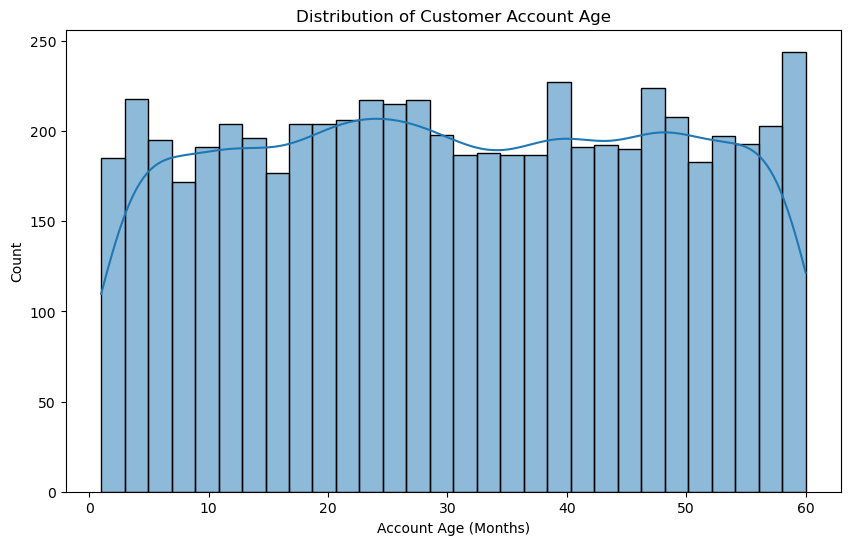

In [30]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['account_age_months'],
    kde=True,
    bins=30
)

plt.title('Distribution of Customer Account Age')
plt.xlabel('Account Age (Months)')

plt.show()

- the distribution is relatively balanced without extreme skewness.
- customer base is dominated by moderately experienced users.
- most loyal customers gave their 5 years to the platform using it.

In [32]:
df['avg_order_value'].describe()

count    6000.000000
mean       80.487945
std        55.044707
min        10.000000
25%        44.525000
50%        67.225000
75%       100.685000
max      1006.530000
Name: avg_order_value, dtype: float64

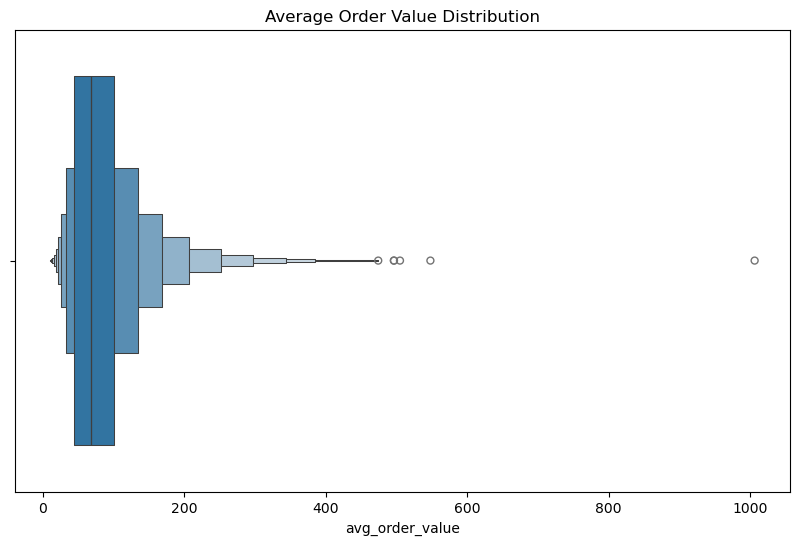

In [35]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    x=df['avg_order_value']
)

plt.title('Average Order Value Distribution')

plt.show()

- most customers spend within a moderate range.
- Premium spending behavior exist,but is limited.
- revenue may depend on smallerb high_value customers segment.

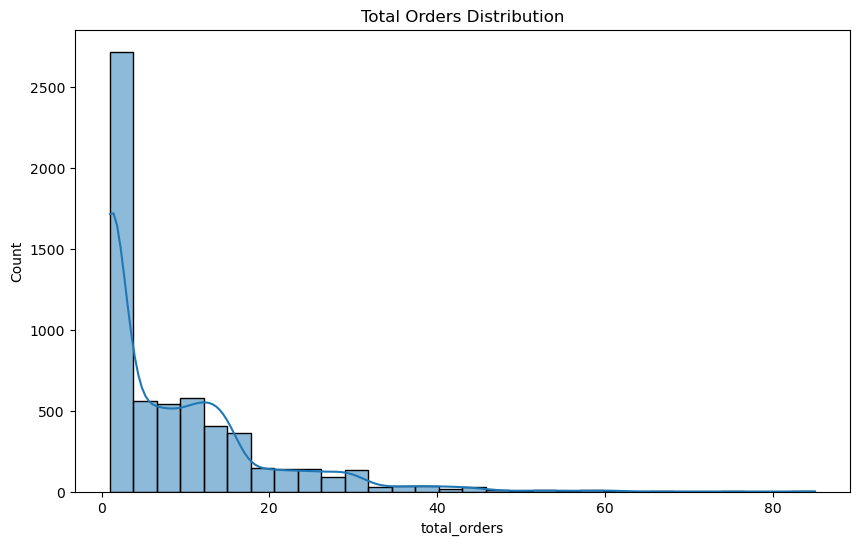

In [36]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['total_orders'],
    kde=True,
    bins=30
)

plt.title('Total Orders Distribution')

plt.show()

- most customers place a moderate number of orders.
- extremely  high order customers are rare.
- heavy repeat buying customers form a small segment

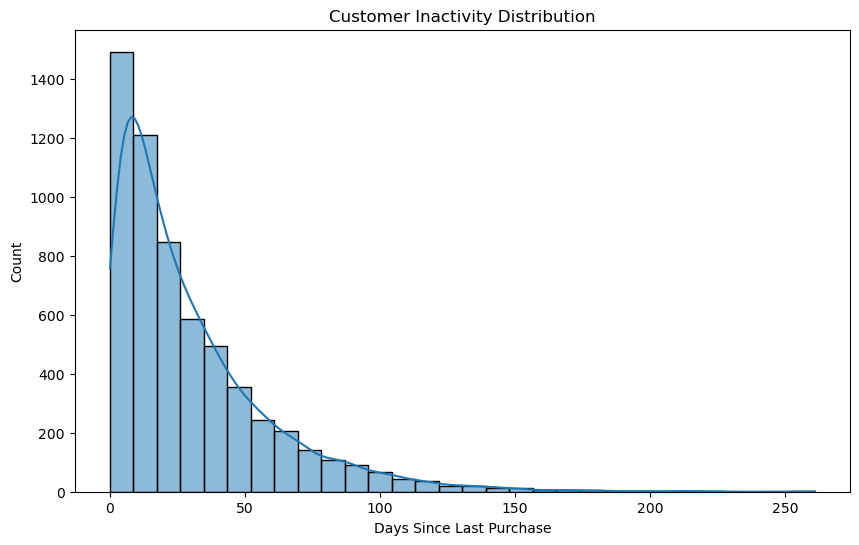

In [39]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['days_since_last_purchase'],
    kde=True,
    bins=30
)

plt.title('Customer Inactivity Distribution')

plt.xlabel('Days Since Last Purchase')

plt.show()

- right skewed
- A long inactivity tail exist in the dataset.
- many customers purchased recently.
- more days since last purchase days show the disengagement behavior of the customer.

In [41]:
df['discount_usage_rate'].describe()

count    6000.000000
mean        0.285057
std         0.158112
min         0.003000
25%         0.162000
50%         0.265000
75%         0.387000
max         0.895000
Name: discount_usage_rate, dtype: float64

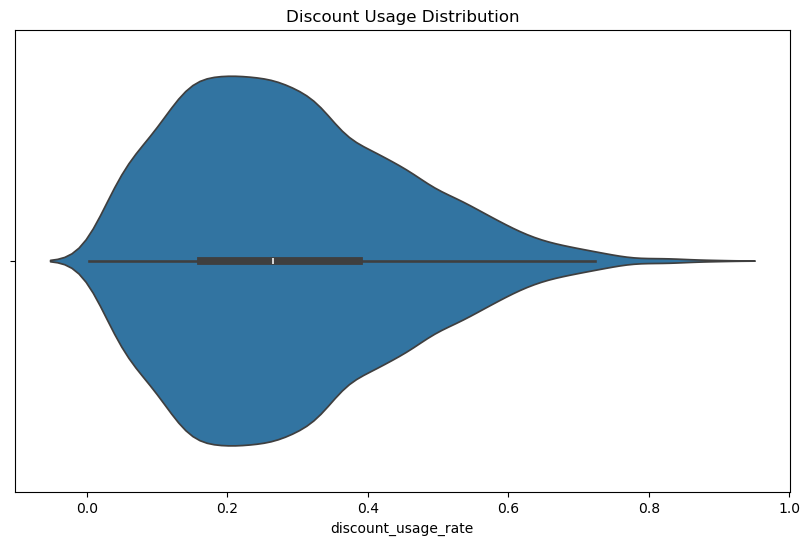

In [40]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x=df['discount_usage_rate']
)

plt.title('Discount Usage Distribution')

plt.show()

-  noticeable group of people mostly relies on discount.
- these group of customers can churn when the dis is not offered.
- so the price sensitive customers are clearly peresent.

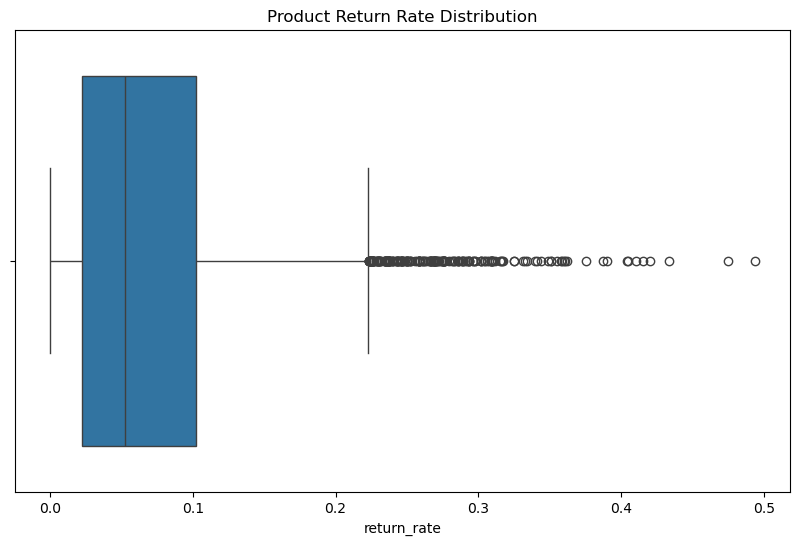

In [42]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['return_rate']
)

plt.title('Product Return Rate Distribution')

plt.show()

- Extreme return behavior exists among some users.
- A smaller segment returns products frequently.

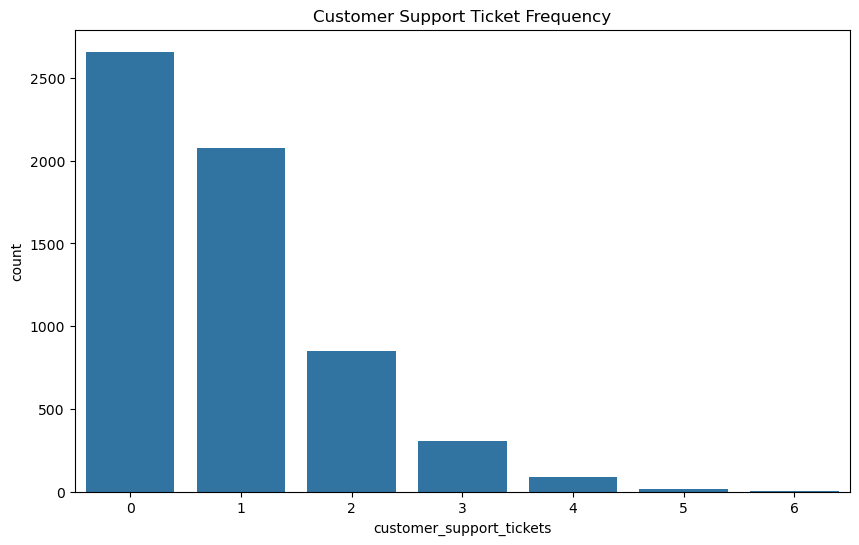

In [43]:
plt.figure(figsize=(10,6))

sns.countplot(
    x=df['customer_support_tickets']
)

plt.title('Customer Support Ticket Frequency')

plt.show()

**1 problem = 1 ticket**

In [44]:
df['customer_support_tickets'].nunique()

7

- Most customers raise very few support tickets.
- Majority of users experience limited operational friction.
- A smaller segment requires repeated customer assistance,which can cause support fatigue and can lead to churn

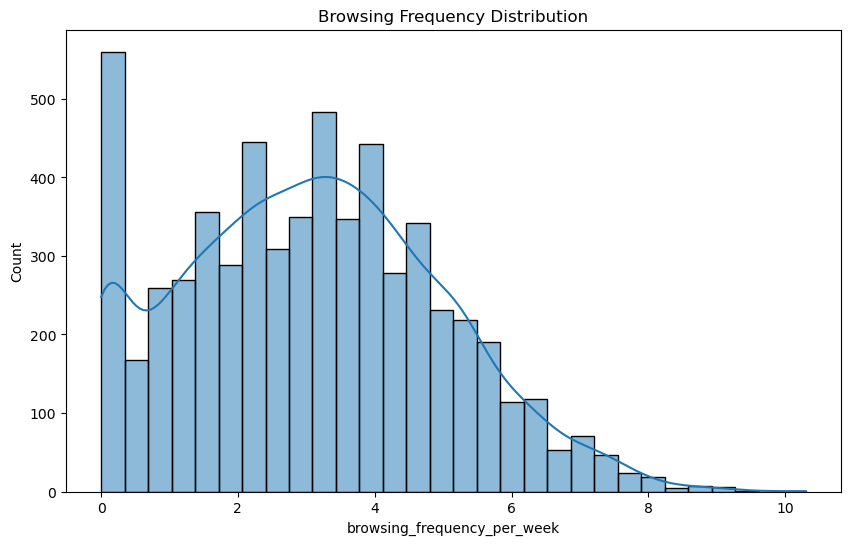

In [45]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['browsing_frequency_per_week'],
    kde=True,
    bins=30
)

plt.title('Browsing Frequency Distribution')

plt.show()

- most customers browse the platform almost regularly.
- It shows the strong behavioral pattern.
- extreme inactive browsing behavior is less common.

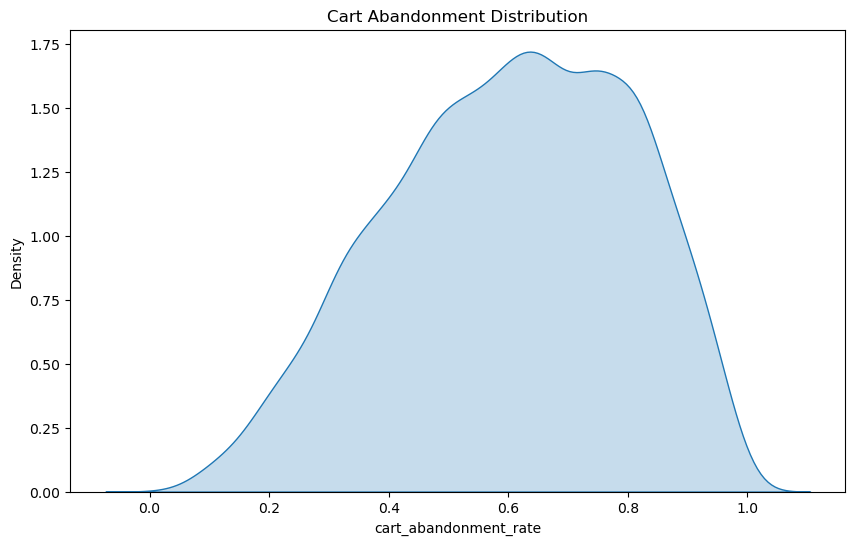

In [46]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    df['cart_abandonment_rate'],
    fill=True
)

plt.title('Cart Abandonment Distribution')

plt.show()

- Purchase hesitation is common within the platform.
- Checkout friction likely affects customer conversion.
- maybe they would be waiting for the discount or the reduce in the price.

C:\Users\Asus\AppData\Local\Temp\ipykernel_10296\3991995417.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='score_range', palette='viridis')


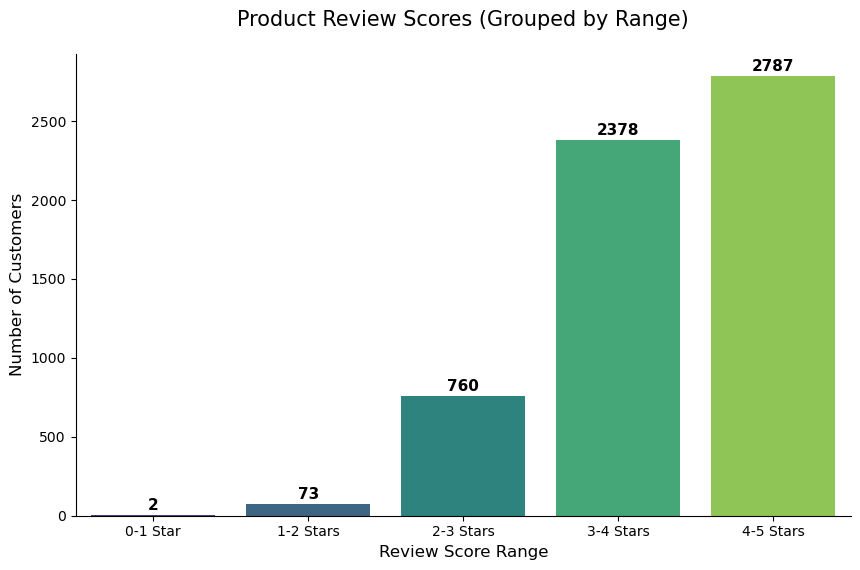

In [50]:

bins = [0, 1, 2, 3, 4, 5]
labels = ['0-1 Star', '1-2 Stars', '2-3 Stars', '3-4 Stars', '4-5 Stars']
df['score_range'] = pd.cut(df['product_review_score_avg'], bins=bins, labels=labels)

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='score_range', palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=11, color='black', 
                xytext=(0, 7), 
                textcoords='offset points',
                fontweight='bold')


plt.title('Product Review Scores (Grouped by Range)', fontsize=15, pad=20)
plt.xlabel('Review Score Range', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
sns.despine() 
plt.show()

- Extremely low ratings are less frequent.
- Customers are generally moderately satisfied with products.

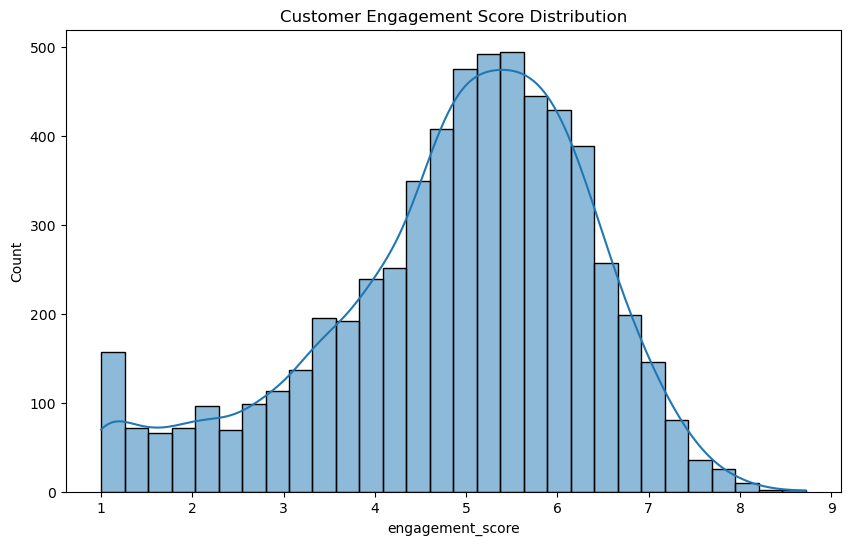

In [52]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['engagement_score'],
    kde=True,
    bins=30
)

plt.title('Customer Engagement Score Distribution')

plt.show()

- Highly engaged users form an important customer segment.
- Majority of users show moderate engagement behavior.
- engagement distribution shows clear behavioral diversity.

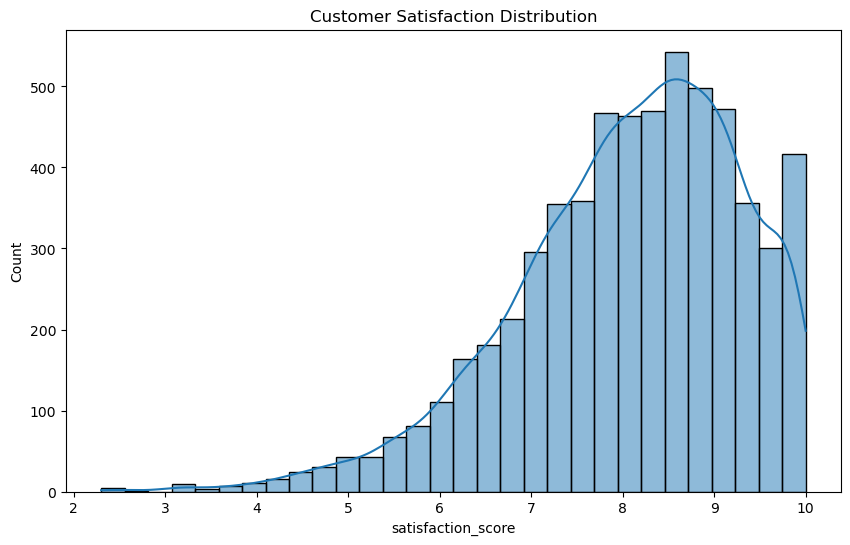

In [56]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['satisfaction_score'],
    kde=True,
    bins=30
)

plt.title('Customer Satisfaction Distribution')

plt.show()

In [57]:
df['satisfaction_score'].describe()

count    6000.000000
mean        8.069722
std         1.241928
min         2.300000
25%         7.320000
50%         8.230000
75%         9.000000
max        10.000000
Name: satisfaction_score, dtype: float64

- most customers have relatively good satisfaction score.
- Extremely dissatisfied users are limited.
- Overall customer experience appears reasonably positive.  

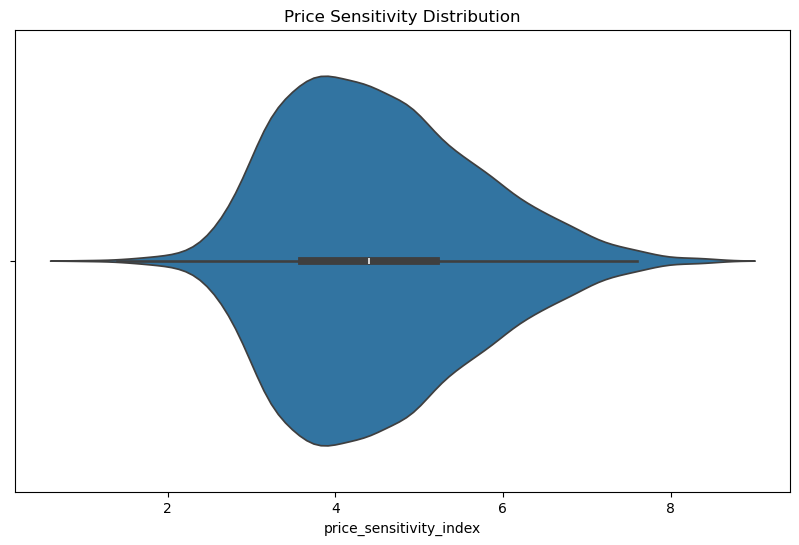

In [58]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x=df['price_sensitivity_index']
)

plt.title('Price Sensitivity Distribution')

plt.show()

In [59]:
df['price_sensitivity_index'].describe()

count    6000.000000
mean        4.513517
std         1.150608
min         1.000000
25%         3.600000
50%         4.400000
75%         5.200000
max         8.600000
Name: price_sensitivity_index, dtype: float64

- Both value-seeking and less price-sensitive segments exist.
- Pricing strategy impacts different customer groups differently.
- Some customers react strongly to pricing changes. 

# CATEGORICAL FEATURES

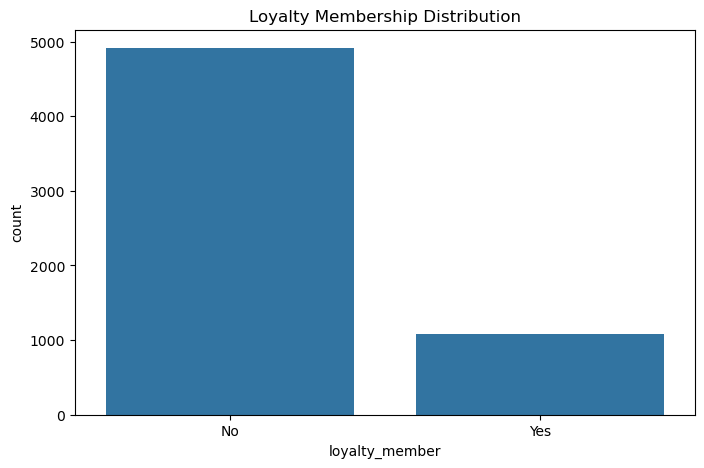

In [60]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df['loyalty_member']
)

plt.title('Loyalty Membership Distribution')

plt.show()

- customers with membership are less likely to churn.
- in this dataset we have less no  of loyalty members.

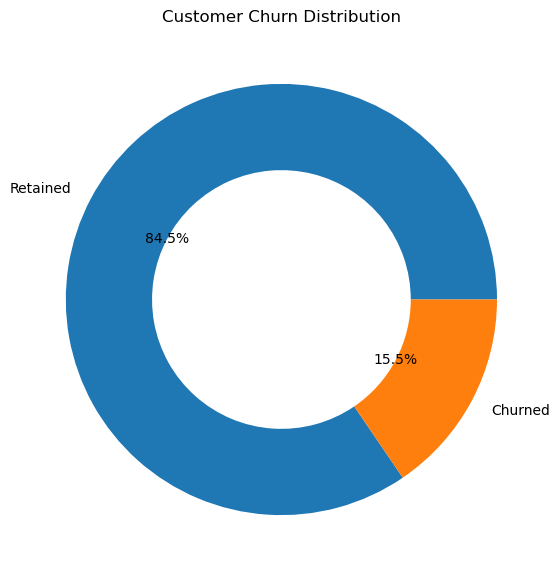

In [61]:
churn_counts = df['churned'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    churn_counts,
    labels=['Retained', 'Churned'],
    autopct='%1.1f%%',
    wedgeprops={'width':0.4}
)

plt.title('Customer Churn Distribution')

plt.show()

- majority of the customers are retained.
- dataset contains enough churn cases for meanigful analysis.

# Bivariate analysis

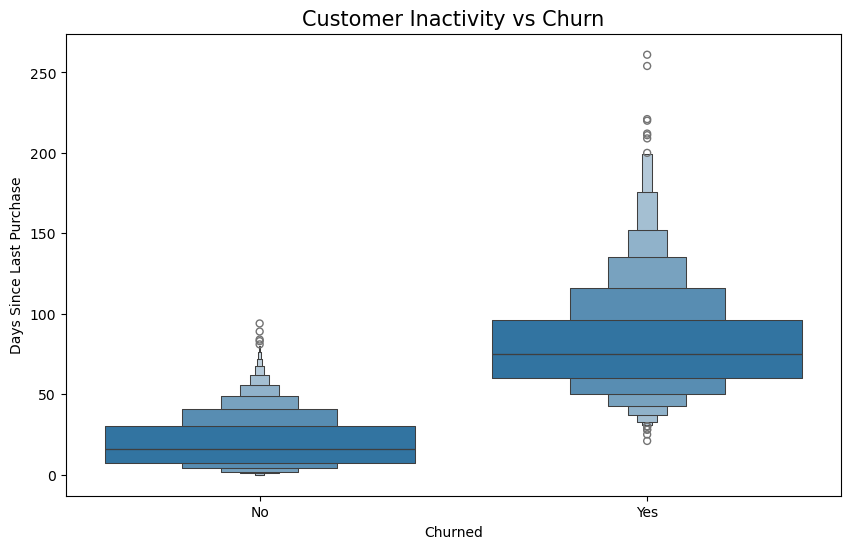

In [62]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    data=df,
    x='churned',
    y='days_since_last_purchase'
)

plt.title('Customer Inactivity vs Churn', fontsize=15)
plt.xlabel('Churned')
plt.ylabel('Days Since Last Purchase')

plt.show()

- retained customers purchase much more recently.
- Inactivity is one of the strongest churn signals.
- customer psychologically disengage before fully leaving.
- churned customers show significantly higher inactivity.

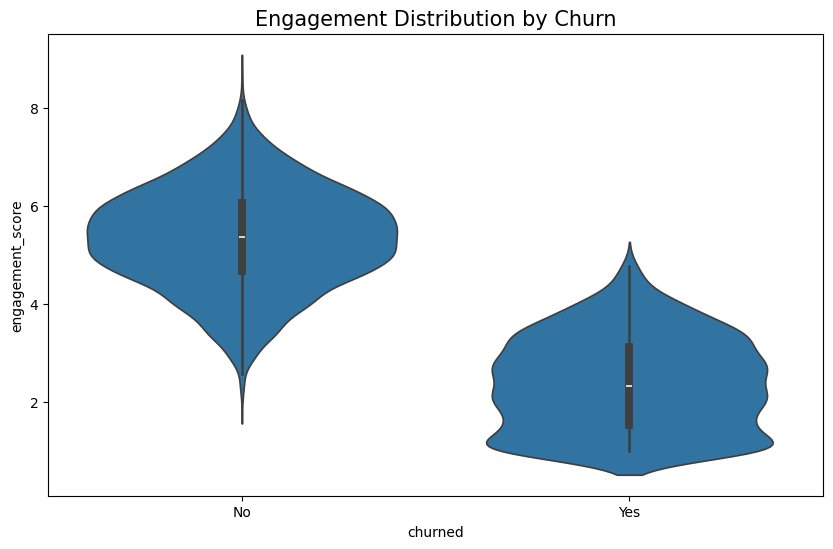

In [63]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='churned',
    y='engagement_score'
)

plt.title('Engagement Distribution by Churn', fontsize=15)

plt.show()

- Engagement clearly separates loyal vs risky customers.
- Low engagement acts as an early warning signal.
- Retained customers have much higher engagement score.
- Churned users are concentrated at low engagement values.

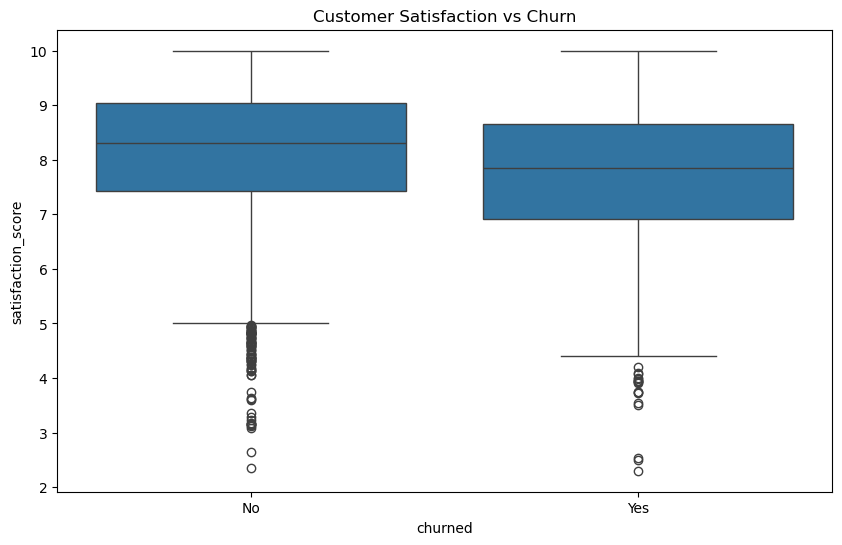

In [64]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='churned',
    y='satisfaction_score'
)

plt.title('Customer Satisfaction vs Churn')

plt.show()

- the median line of retained customers is far above than that of churned customer which mean typically the  retained  customer is more satisfied as compared to that of the churn customers.

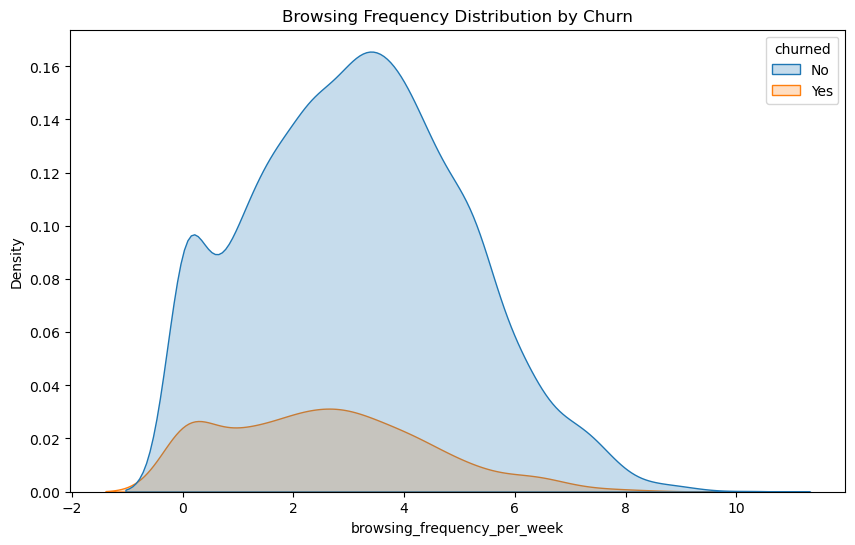

In [65]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='browsing_frequency_per_week',
    hue='churned',
    fill=True
)

plt.title('Browsing Frequency Distribution by Churn')

plt.show()

- Retained users browse more frequently.
- Churned customers interact less with the platform.
- Reduced browsing reflects declining interest.
- Attention decline happens before churn.

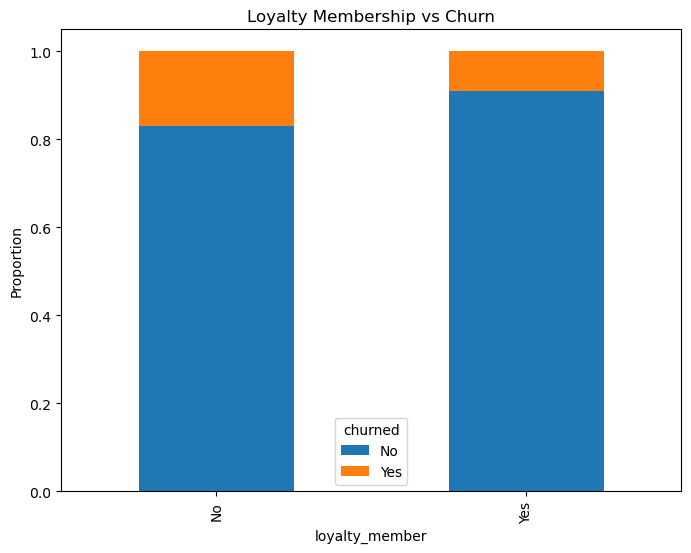

In [66]:
loyalty_churn = pd.crosstab(
    df['loyalty_member'],
    df['churned'],
    normalize='index'
)

loyalty_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,6)
)

plt.title('Loyalty Membership vs Churn')
plt.ylabel('Proportion')

plt.show()

- Loyalty members churn less frequently.
- Reward systems increase customer stickiness.
- loyalty program improve the retension consistency.
- customers with membership shows switching resistance.

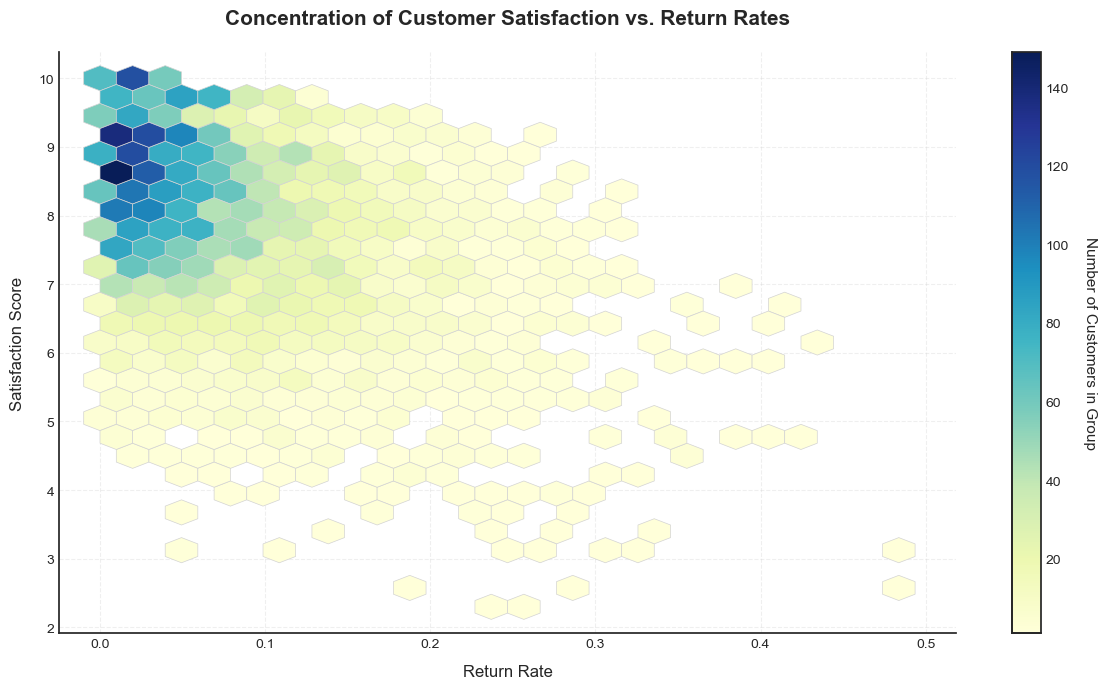

In [70]:
plt.style.use('seaborn-v0_8-white') 

plt.figure(figsize=(12, 7))
hb = plt.hexbin(
    df['return_rate'], 
    df['satisfaction_score'], 
    gridsize=25, 
    cmap='YlGnBu', 
    mincnt=1, 
    edgecolors='lightgrey',
    linewidths=0.5
)

plt.xlabel('Return Rate', fontsize=12, labelpad=10)
plt.ylabel('Satisfaction Score', fontsize=12, labelpad=10)
plt.title('Concentration of Customer Satisfaction vs. Return Rates', fontsize=15, pad=20, fontweight='bold')

cb = plt.colorbar(hb)
cb.set_label('Number of Customers in Group', fontsize=11, rotation=270, labelpad=20)

plt.grid(True, linestyle='--', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

- High return rates cluster around lower satisfaction.
- Product dissatisfaction contributes to retention problems.
- Most loyal customers show low returns and high satisfaction.
- Return behavior reflects customer experience quality.

# Multivariate analysis

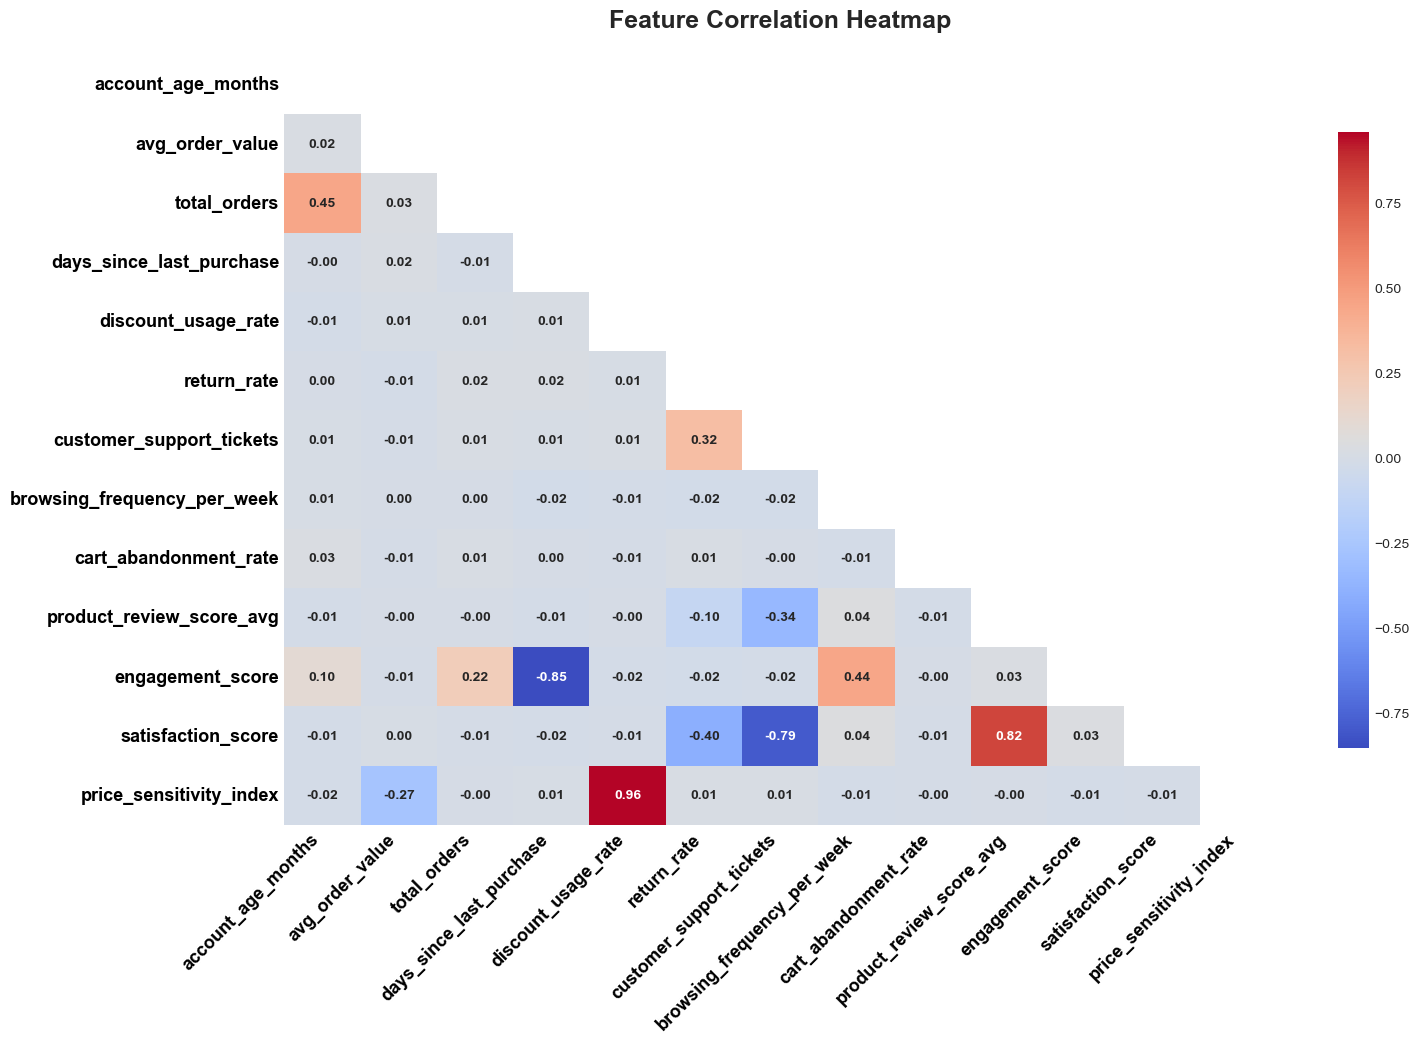

In [72]:
corr = df.select_dtypes(include='number').corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 10))

ax = sns.heatmap(
    corr, 
    mask=mask,
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f',
    annot_kws={"size": 10, "weight": "bold"}, 
    cbar_kws={"shrink": .8}
)

plt.xticks(
    fontsize=13, 
    fontweight='bold', 
    color='black', 
    rotation=45, 
    ha='right'
)

plt.yticks(
    fontsize=13, 
    fontweight='bold', 
    color='black'
)

plt.title('Feature Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.show()

- Engagement and satisfaction are strongly positively related.
- Inactivity has strong positive relation with churn.
- Engagement negatively correlates with churn.
- Customer behavior features are more powerful than pricing features.
- Satisfaction Score & Support Tickets (-0.79): This is a huge insight. As the number of support tickets increases, satisfaction crashes

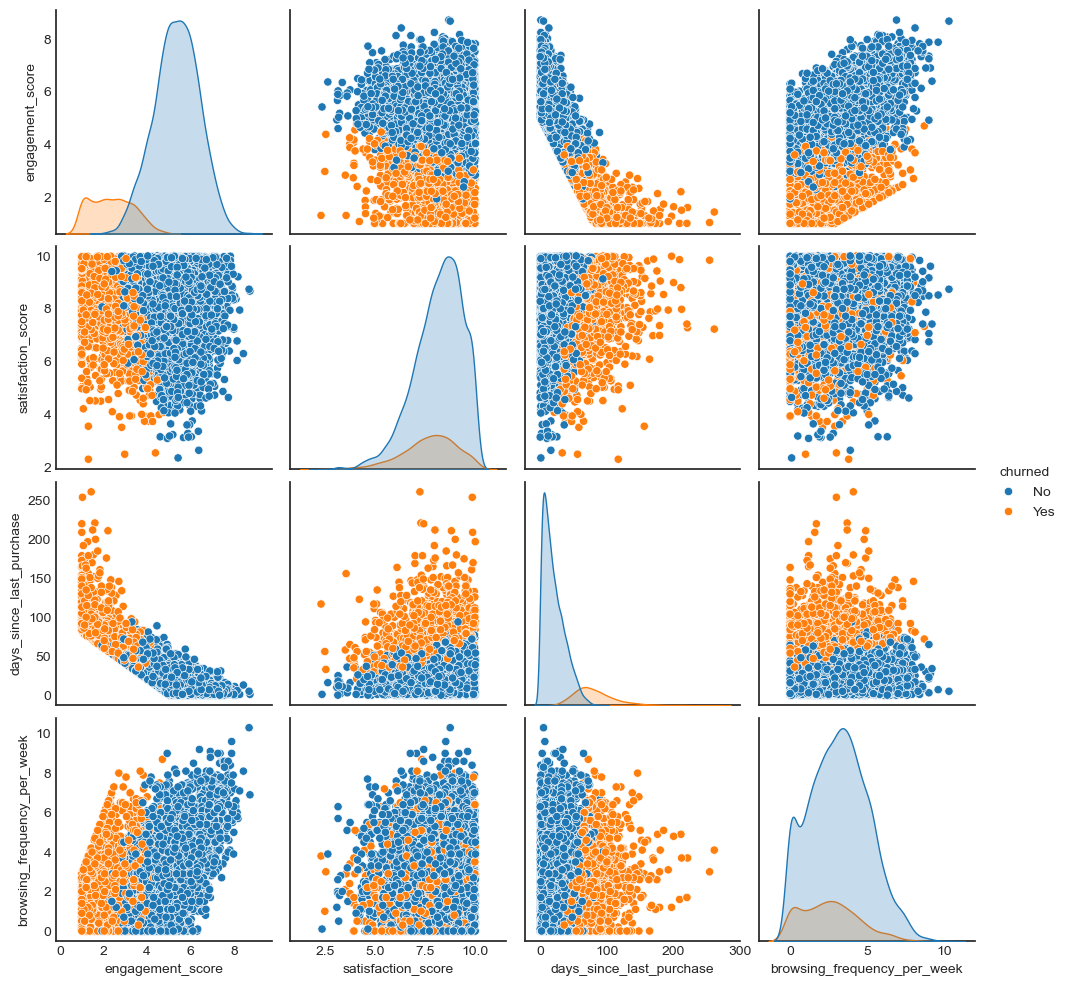

In [73]:
sns.pairplot(
    df[[
        'engagement_score',
        'satisfaction_score',
        'days_since_last_purchase',
        'browsing_frequency_per_week',
        'churned'
    ]],
    hue='churned'
)

plt.show()

- Retained customers occupy high-engagement regions
- Behavioral variables separate churn surprisingly well.
- there is a "Danger Zone" below an engagement score of ~4. If a customer's engagement drops below this, they are almost guaranteed to churn.
- As the days since the last purchase increase, the engagement score drops in a sharp curve, and the color turns Orange. This proves that "silence" is the first step toward churn.
- some orange dots (churners) still have high satisfaction scores (7-9),this means some people leave even when they are happy with the product—likely because of price or a competitor's offer.

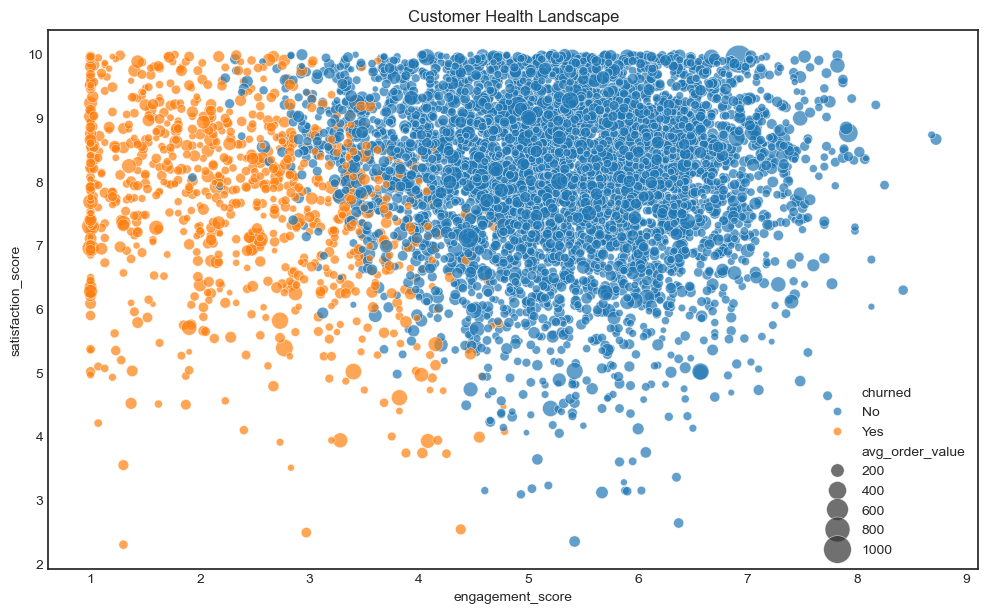

In [76]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df,
    x='engagement_score',
    y='satisfaction_score',
    size='avg_order_value',
    hue='churned',
    sizes=(20,400),
    alpha=0.7
)

plt.title('Customer Health Landscape')

plt.show()

- It doesn't matter how satisfied a customer is (even if they have a 10/10 score); if they aren't engaging with the app/site, they are highly likely to leave. Activity is more important than happiness for retention.
- There are many orange dots that have a Satisfaction Score of 9 or 10 but an Engagement Score of 1 or 2.These are people who like your product but have simply stopped using it. They didn't leave because they were "angry" (low satisfaction); they left because they "forgot" or found a new habit.

<Figure size 1200x800 with 0 Axes>

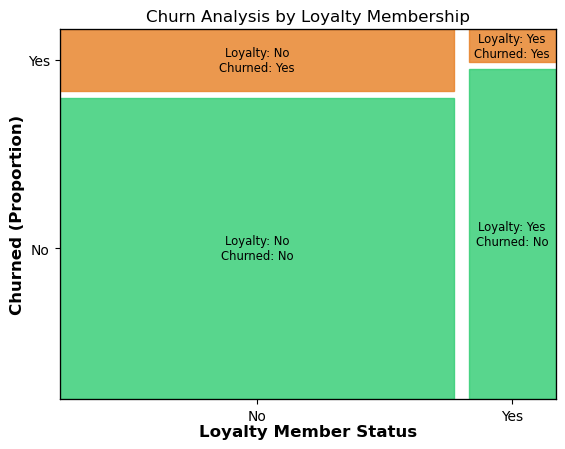

In [80]:
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

# 1. Create a function to label each tile clearly
# 'key' is a tuple like ('Yes', 'No') representing (loyalty_member, churned)
label_dict = lambda key: f"Loyalty: {key[0]}\nChurned: {key[1]}"

# 2. Setup the colors (Pro tip: use distinct colors for 'Yes' and 'No' churn)
props = lambda key: {
    'color': '#2ecc71' if 'No' in key[1] else '#e67e22', # Green for Stayed, Orange for Churn
    'alpha': 0.8
}

plt.figure(figsize=(12, 8))

# 3. Create the Mosaic
mosaic(
    df, 
    ['loyalty_member', 'churned'], 
    labelizer=label_dict, # This puts "Loyalty: Yes / Churned: No" inside the boxes
    properties=props,
    gap=0.03,             # Adds a clean space between the blocks
    title='Churn Analysis by Loyalty Membership'
)

# 4. Add axis labels for extra clarity
plt.text(-0.1, 0.5, 'Churned (Proportion)', va='center', rotation='vertical', fontsize=12, fontweight='bold')
plt.text(0.5, -0.1, 'Loyalty Member Status', ha='center', fontsize=12, fontweight='bold')

plt.show()

- Loyalty membership visibly reduces churn proportion.
- Non-members dominate churn segments.
- Membership status strongly influences retention behavior.

# final EDA report

This E-Commerce Customer Churn EDA focused on understanding the behavioral, engagement, and satisfaction patterns influencing customer retention.

The analysis revealed that churn is primarily a behavioral disengagement problem rather than purely a pricing issue.

**key findings**: 
- **Customer Inactivity Is the Strongest Churn Signal:**

- Customers with longer inactivity periods are significantly more likely to churn.

- The dataset clearly shows that disengagement starts long before customers fully leave the platform.

- **Engagement Strongly Drives Retention**

- Highly engaged customers:

- browse more
- purchase more
- remain active longer
- churn less frequently

**Engagement score is one of the most powerful behavioral indicators in the dataset.**

- **Loyalty Programs Improve Customer Stickiness**

- Loyalty members demonstrate:

- lower churn rates
- stronger engagement
- more consistent activity

This indicates that reward ecosystems improve customer retention.

- **Behavioral Features Are More Powerful Than Spending Features**

Features like:

- engagement
- inactivity
- browsing behavior
- satisfaction

show much stronger churn relationships than pure spending variables like average order value.



# Final Conclusion
**The dataset reveals a clear customer churn journey:**

- Engagement decreases
- Browsing activity reduces
- Purchase frequency declines
- Inactivity rises
- Satisfaction weakens
- Customer finally churns

**The strongest retention drivers are:**

- engagement
- activity consistency
- satisfaction
- loyalty participation